"""
# Flagging Vendor Invoices for Manual Review

Objective: Predict whether a vendor invoice should be flagged for manual approval 
based on abnormal cost, freight, or delivery patterns, in order to reduce 
financial risk, improve operational efficiency, and prioritize human review 
where it adds the most value.

* Manual invoice review is time-consuming and does not scale with transaction volume.
* Abnormal freight charges, pricing deviations, or delivery delays often indicate 
  errors, disputes, or compliance risks.
* An automated flagging system enables finance teams to focus attention on 
  high-risk invoices while allowing low-risk invoices to be processed automatically.
"""


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect(r'C:\Users\PMLS\Documents\IBM Data Analytics\All_Projects\Python_Project\Inventroy db\data\inventory.db')

In [5]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [6]:
for table in tables['name']:
    print('Table Name', table)
    df = pd.read_sql_query(f'Select * from {table} limit 5', conn)
    display(df)

Table Name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table Name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table Name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table Name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table Name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [ ]:
purchase_agg_df = pd.read_sql_query("""
select
PONumber,
count(distinct(Brand)) as total_brand,                                 
sum(Quantity) as total_item_quantity,
sum(Dollars) as total_item_dollars,
avg(julianday(ReceivingDate) - julianday(PODate)) as avg_receiving_delay
from purchases
group by PONumber                                                                                          
""", conn)

In [25]:
purchase_agg_df.shape

(5543, 5)

In [24]:
pd.read_sql_query("""
select
Quantity as invoice_quantity,                 
Dollars as invoice_dollars,
Freight,
(julianday(InvoiceDate) - julianday(PODate)) as days_po_to_invoice,
(julianday(PayDate) - julianday(InvoiceDate)) as days_to_pay                                                
from vendor_invoice """,conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [44]:
df = pd.read_sql_query("""

With Purchase_agg as(
select
p.PONumber,
count(distinct(p.Brand)) as total_brand,                                 
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber                  
)                                  
select
    vi.Quantity as invoice_quantity,                 
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
    pa.total_brand,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay                                                                  
from vendor_invoice vi  
left join purchase_agg pa
on vi.PONumber = pa.PONumber                                                                
""",conn)

In [45]:
df

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brand,total_item_quantity,total_item_dollars,avg_receiving_delay
0,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [46]:
df.isnull().sum()

invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brand            0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [47]:
df.dtypes

invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brand              int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [50]:
df.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brand,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,35.0,41.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,6.0,77.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,23.0,1.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,31.0,3.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,35.0,7.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,40.0,46.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,48.0,807.0,141660.0,1660436.0,13.0


In [51]:
def create_invoice_risk_label(row):
    
    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"])) > 5:
        return 1
    
    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
        
    return 0

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

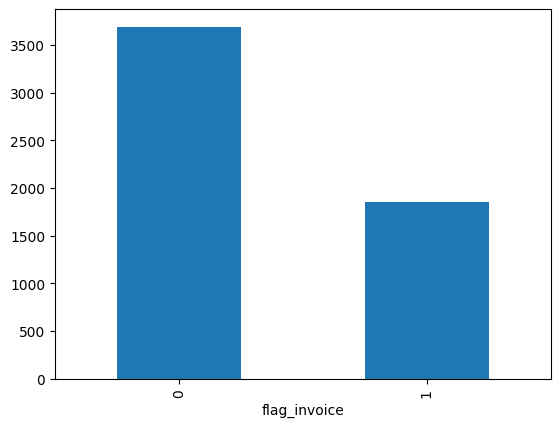

In [52]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

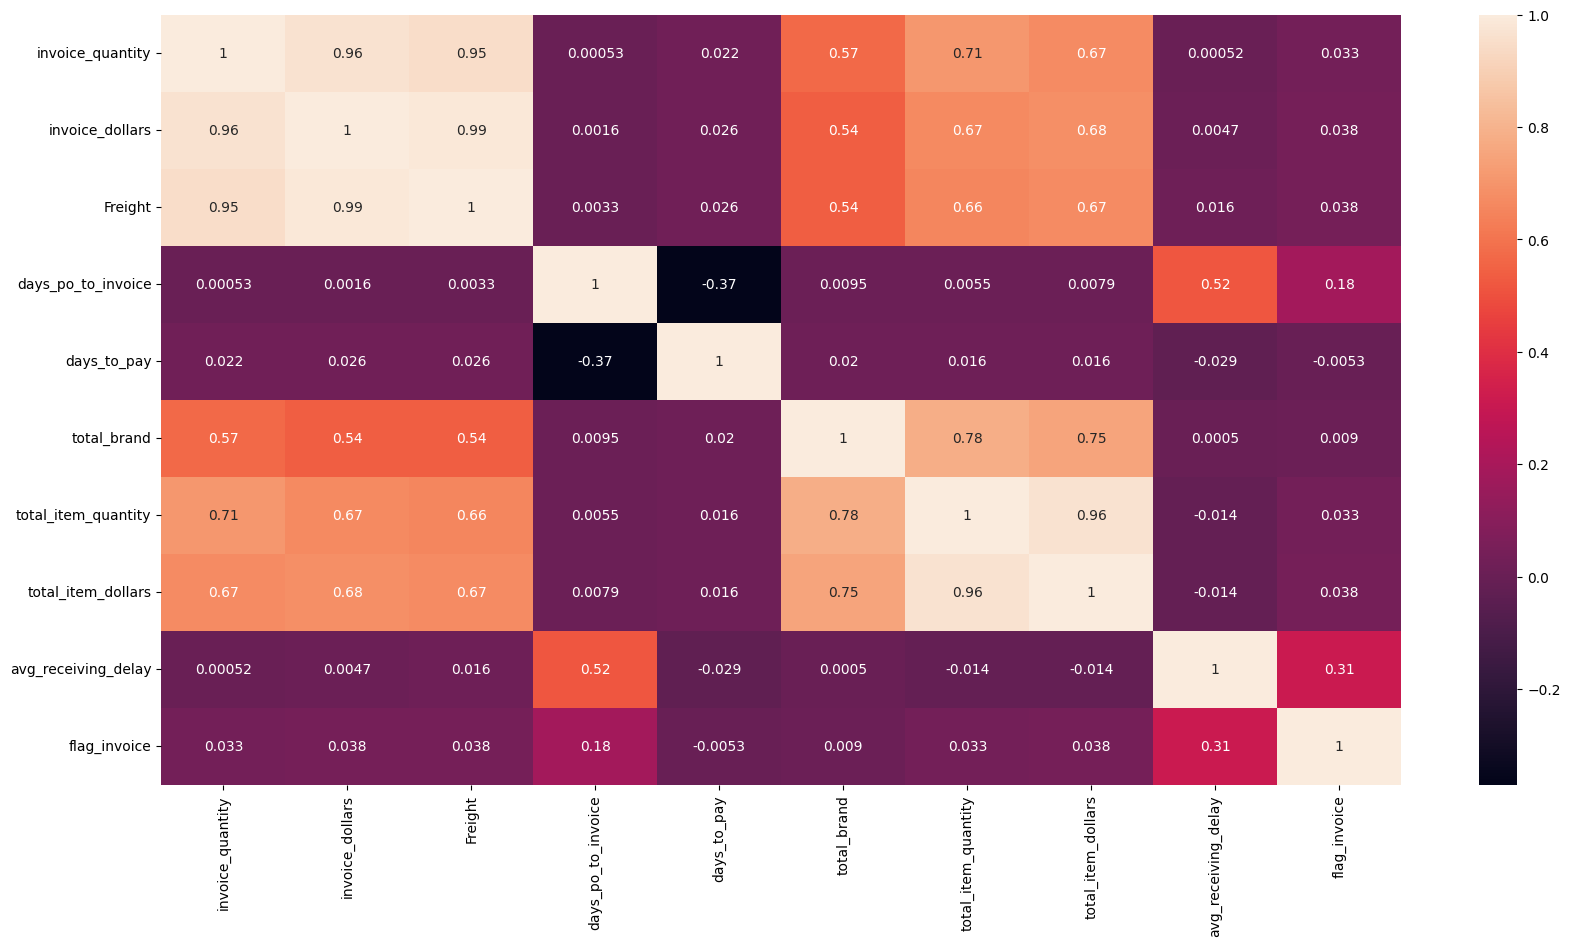

In [53]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot= True)
plt.show()